In [1]:
# change file type pandas or numpy
import pandas as pd
import numpy as np

path = 'heart.csv'

df = pd.read_csv(path, index_col=0) # index_col = 0을 통해서 컬럼 갯수 제거
df.head()

,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal,target
age,,,,,,,,,,,,,
63,1,3,145,233,1,0,150,0,2.3,0,0,1,1
37,1,2,130,250,0,1,187,0,3.5,0,0,2,1
41,0,1,130,204,0,0,172,0,1.4,2,0,2,1
56,1,1,120,236,0,1,178,0,0.8,2,0,2,1
57,0,0,120,354,0,1,163,1,0.6,2,0,2,1


classfication

In [2]:
clf_df = df # move df to classfication df
y = clf_df['target']             # target
y.head()

age
63    1
37    1
41    1
56    1
57    1
Name: target, dtype: int64

In [3]:
X = clf_df.drop('target', axis=1) # fitting data
X.head()

,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
age,,,,,,,,,,,,
63,1,3,145,233,1,0,150,0,2.3,0,0,1
37,1,2,130,250,0,1,187,0,3.5,0,0,2
41,0,1,130,204,0,0,172,0,1.4,2,0,2
56,1,1,120,236,0,1,178,0,0.8,2,0,2
57,0,0,120,354,0,1,163,1,0.6,2,0,2


In [4]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,train_size=0.25,random_state=0)

In [8]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier
from sklearn.neighbors import KNeighborsClassifier

lg_model = LogisticRegression(random_state=0)
lg_model.fit(X_train,y_train)
lg_y = lg_model.predict(X_test)

De_model = DecisionTreeClassifier(random_state=0)
De_model.fit(X_train,y_train)
De_y = lg_model.predict(X_test)

Rd_model = RandomForestClassifier(random_state=0)
Rd_model.fit(X_train,y_train)
Rd_y = lg_model.predict(X_test)

KN_model = KNeighborsClassifier(n_neighbors=5)
KN_model.fit(X_train,y_train)
KN_y = KN_model.predict(X_test)

c:\Users\June\AppData\Local\Programs\Python\Python313\Lib\site-packages\sklearn\linear_model\_logistic.py:406: ConvergenceWarning: lbfgs failed to converge after 100 iteration(s) (status=1):
STOP: TOTAL NO. OF ITERATIONS REACHED LIMIT

Increase the number of iterations to improve the convergence (max_iter=100).
You might also want to scale the data as shown in:
    https://scikit-learn.org/stable/modules/preprocessing.html
Please also refer to the documentation for alternative solver options:
    https://scikit-learn.org/stable/modules/linear_model.html#logistic-regression
  n_iter_i = _check_optimize_result(


In [9]:
from sklearn.metrics import accuracy_score # 정확도
from sklearn.metrics import confusion_matrix #혼동행렬 ==> k fold

print('---- logistic regression ----')
print(accuracy_score(y_test, lg_y))
print(confusion_matrix(y_test, lg_y))

print('---- decision tree classifier ----')
print(accuracy_score(y_test, De_y))
print(confusion_matrix(y_test, De_y))

print('---- random forest classifier ----')
print(accuracy_score(y_test, Rd_y))
print(confusion_matrix(y_test, Rd_y))

print('---- KNeighborsClassifier ----')
print(accuracy_score(y_test, KN_y))
print(confusion_matrix(y_test, KN_y))

---- logistic regression ----
0.8289473684210527
[[ 79  24]
 [ 15 110]]
---- decision tree classifier ----
0.8289473684210527
[[ 79  24]
 [ 15 110]]
---- random forest classifier ----
0.8289473684210527
[[ 79  24]
 [ 15 110]]
---- KNeighborsClassifier ----
0.6403508771929824
[[70 33]
 [49 76]]


In [ ]:
# k value 최적화



regression

In [11]:
# 데이터 상관관계 확인
import seaborn as sns
import matplotlib.pyplot as plt

reg_df = df # move df to classfication df
reg_df = reg_df.drop('target', axis=1)
reg_df
# corr = reg_df.corr()

# #sns.heatmap(corr, annot=True, fmt='.0f', cmap='coolwarm')
# sns.heatmap(corr)
# plt.show()

,sex,cp,trestbps,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
age,,,,,,,,,,,,
63,1,3,145,233,1,0,150,0,2.3,0,0,1
37,1,2,130,250,0,1,187,0,3.5,0,0,2
41,0,1,130,204,0,0,172,0,1.4,2,0,2
56,1,1,120,236,0,1,178,0,0.8,2,0,2
57,0,0,120,354,0,1,163,1,0.6,2,0,2
...,...,...,...,...,...,...,...,...,...,...,...,...
57,0,0,140,241,0,1,123,1,0.2,1,0,3
45,1,3,110,264,0,1,132,0,1.2,1,0,3
68,1,0,144,193,1,1,141,0,3.4,1,2,3


In [20]:
y = reg_df['trestbps']             # target
y.head() 

age
63    145
37    130
41    130
56    120
57    120
Name: trestbps, dtype: int64

In [21]:
X = reg_df.drop('trestbps', axis=1) # fitting data
X.head()

,sex,cp,chol,fbs,restecg,thalach,exang,oldpeak,slope,ca,thal
age,,,,,,,,,,,
63,1,3,233,1,0,150,0,2.3,0,0,1
37,1,2,250,0,1,187,0,3.5,0,0,2
41,0,1,204,0,0,172,0,1.4,2,0,2
56,1,1,236,0,1,178,0,0.8,2,0,2
57,0,0,354,0,1,163,1,0.6,2,0,2


In [22]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X,y,train_size=0.25,random_state=0)

In [23]:
from sklearn.linear_model import LinearRegression
from sklearn.tree import DecisionTreeRegressor
from sklearn.ensemble import RandomForestRegressor
from sklearn.neighbors import KNeighborsRegressor

lg_model = LinearRegression()
lg_model.fit(X_train,y_train)
lg_y = lg_model.predict(X_test)

De_model = DecisionTreeRegressor()
De_model.fit(X_train,y_train)
De_y = lg_model.predict(X_test)

Rd_model = RandomForestRegressor()
Rd_model.fit(X_train,y_train)
Rd_y = lg_model.predict(X_test)

KN_model = KNeighborsRegressor(n_neighbors=5)
KN_model.fit(X_train,y_train)
KN_y = KN_model.predict(X_test)

In [24]:
from sklearn.metrics import mean_squared_error # 평균제곱오차

print('---- LinearRegression ----')
print(mean_squared_error(y_test,lg_y))
print('---- DecisionTreeRegressor ----')
print(mean_squared_error(y_test,De_y))
print('---- RandomForestRegressor ----')
print(mean_squared_error(y_test,Rd_y))
print('---- KNeighborsRegressor ----')
print(mean_squared_error(y_test,KN_y))

---- LinearRegression ----
342.03780735952427
---- DecisionTreeRegressor ----
342.03780735952427
---- RandomForestRegressor ----
342.03780735952427
---- KNeighborsRegressor ----
356.21561403508775


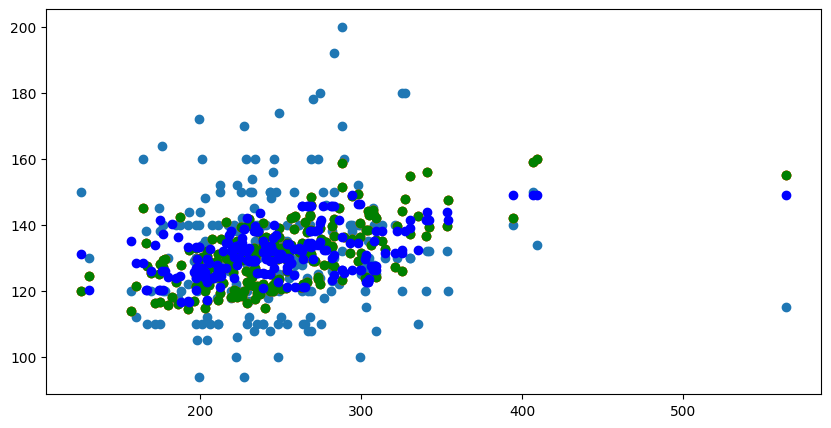

In [25]:
import matplotlib.pyplot as plt
plt.figure(figsize=(10,5))
plt.scatter(X_test['chol'], y_test, label='y_test')
plt.scatter(X_test['chol'], lg_y, c='y', label='lg_y')
plt.scatter(X_test['chol'], De_y, c='r', label='De_y')
plt.scatter(X_test['chol'], Rd_y, c='g', label='Rd_y')
plt.scatter(X_test['chol'], KN_y, c='b', label='KN_y')
#plt.plot(X_train, lr.predict(X_train), color='blue')
plt.show() 